<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week10/day1-2/MNIST_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a Simple Neural Network with TensorFlow/Keras
## Dataset: MNIST Handwritten Digits

In this notebook we will:
1. Load and preprocess the MNIST dataset
2. Build a fully connected neural network
3. Train the model for 10 epochs
4. Evaluate performance with accuracy + a confusion matrix

---
## Step 1 — Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


---
## Step 2 — Load & Preprocess the MNIST Dataset

MNIST contains 70,000 grayscale images of handwritten digits (0–9), each 28x28 pixels.
- 60,000 for training
- 10,000 for testing

We will:
- Normalize pixel values from [0, 255] → [0, 1]
- One-hot encode the labels (e.g. `3` → `[0,0,0,1,0,0,0,0,0,0]`)

In [2]:
# Load MNIST — already split into train/test by Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training set:   {x_train.shape}  |  Labels: {y_train.shape}")
print(f"Test set:       {x_test.shape}  |  Labels: {y_test.shape}")
print(f"Pixel range before normalization: {x_train.min()} to {x_train.max()}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set:   (60000, 28, 28)  |  Labels: (60000,)
Test set:       (10000, 28, 28)  |  Labels: (10000,)
Pixel range before normalization: 0 to 255


In [3]:
# Normalize pixel values to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

print(f"Pixel range after normalization:  {x_train_norm.min()} to {x_train_norm.max()}")

# One-hot encode labels
# e.g. label 5 becomes [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
NUM_CLASSES = 10
y_train_ohe = tf.one_hot(y_train, depth=NUM_CLASSES).numpy()
y_test_ohe  = tf.one_hot(y_test,  depth=NUM_CLASSES).numpy()

print(f"\nExample raw label:     {y_train[0]}")
print(f"Example one-hot label: {y_train_ohe[0]}")

Pixel range after normalization:  0.0 to 1.0

Example raw label:     5
Example one-hot label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


### Visualize Sample Images

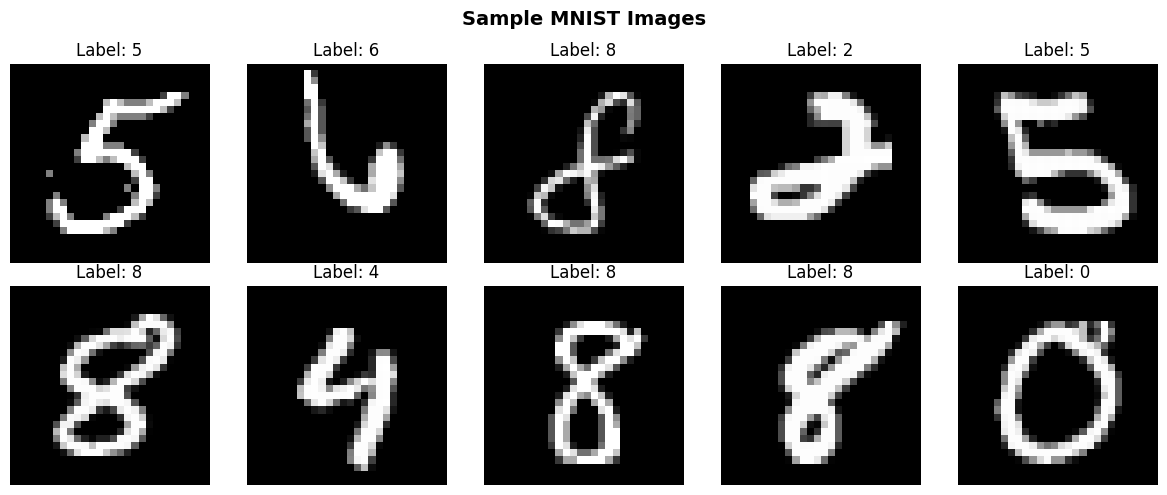

In [4]:
# Display 10 random samples from the training set
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample MNIST Images', fontsize=14, fontweight='bold')

indices = np.random.choice(len(x_train), 10, replace=False)
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[indices[i]], cmap='gray')
    ax.set_title(f'Label: {y_train[indices[i]]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Step 3 — Build the Neural Network

Architecture:
```
Input (28x28) → Flatten (784) → Dense(128, ReLU) → Dense(64, ReLU) → Dense(10, Softmax)
```

- **Flatten**: converts the 2D image into a 1D vector of 784 values
- **Dense (ReLU)**: hidden layers that learn features
- **Dense (Softmax)**: outputs 10 probabilities — one per digit class

In [5]:
model = keras.Sequential([
    # Input: flatten 28x28 image into a 784-element vector
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),

    # Hidden layer 1: 128 neurons, ReLU activation
    keras.layers.Dense(units=128, activation='relu'),

    # Hidden layer 2: 64 neurons, ReLU activation
    keras.layers.Dense(units=64, activation='relu'),

    # Output layer: 10 neurons (one per digit), Softmax for probability distribution
    keras.layers.Dense(units=NUM_CLASSES, activation='softmax')
], name='MNIST_Classifier')

model.summary()

Model: "MNIST_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile the model
# - optimizer='adam'         : adaptive learning rate, works well out of the box
# - loss='categorical_crossentropy' : standard loss for multi-class one-hot labels
# - metrics=['accuracy']     : track classification accuracy during training
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


---
## Step 4 — Train the Model

We train for 10 epochs with a 20% validation split taken from the training data.
Watch the `val_accuracy` — if it diverges from `accuracy`, the model may be overfitting.

In [7]:
print("Starting training...\n")

history = model.fit(
    x_train_norm, y_train_ohe,
    epochs=10,
    batch_size=32,
    validation_split=0.2,    # Use 20% of training data for validation
    verbose=1
)

print("\nTraining complete.")

Starting training...

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9224 - loss: 0.2639 - val_accuracy: 0.9574 - val_loss: 0.1445
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9670 - loss: 0.1106 - val_accuracy: 0.9661 - val_loss: 0.1136
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9762 - loss: 0.0770 - val_accuracy: 0.9717 - val_loss: 0.0934
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9816 - loss: 0.0580 - val_accuracy: 0.9727 - val_loss: 0.0948
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9854 - loss: 0.0433 - val_accuracy: 0.9718 - val_loss: 0.1041
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9892 - loss: 0.0341 - val_accuracy: 0.9719 - val_loss: 0.0977
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9901 - loss: 0.0313 - val_accuracy: 0.9717 - val_loss: 0.1095
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy

### Plot Training History

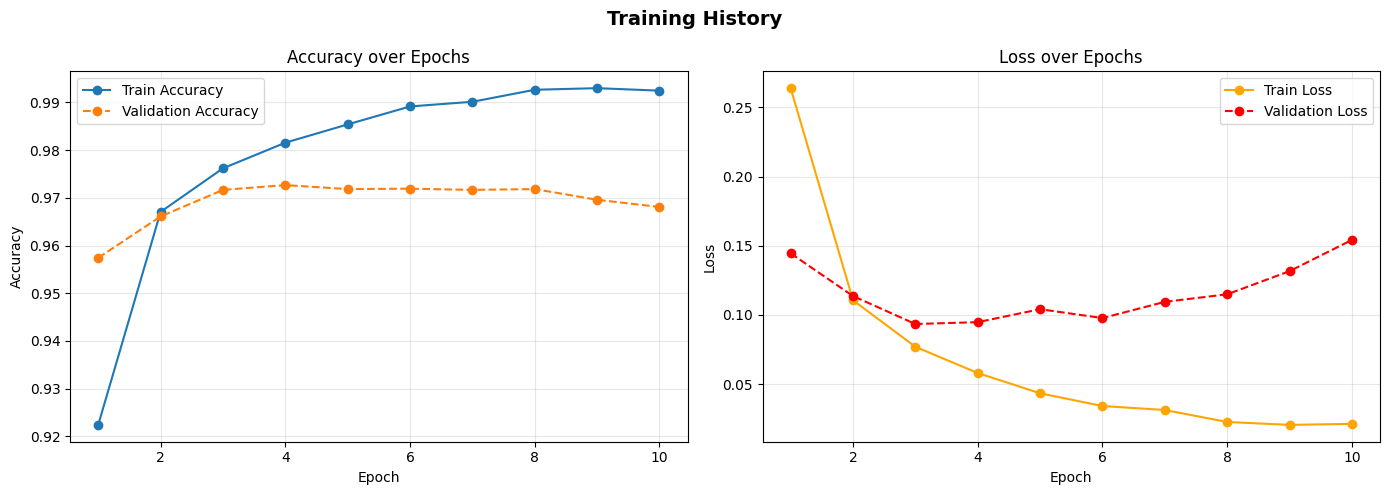

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

epochs_range = range(1, 11)

# Accuracy plot
ax1.plot(epochs_range, history.history['accuracy'],     label='Train Accuracy',      marker='o')
ax1.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy',  marker='o', linestyle='--')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(epochs_range, history.history['loss'],     label='Train Loss',      marker='o', color='orange')
ax2.plot(epochs_range, history.history['val_loss'], label='Validation Loss',  marker='o', linestyle='--', color='red')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 5 — Evaluate the Model

Now we test on the **held-out test set** (10,000 images the model has never seen).

In [9]:
test_loss, test_accuracy = model.evaluate(x_test_norm, y_test_ohe, verbose=0)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Test Loss:     0.1247
Test Accuracy: 0.9719 (97.19%)


### Confusion Matrix

A confusion matrix shows us **where** the model makes mistakes.
The diagonal = correct predictions. Off-diagonal = errors.
Bright off-diagonal cells tell us which digits get confused with each other.

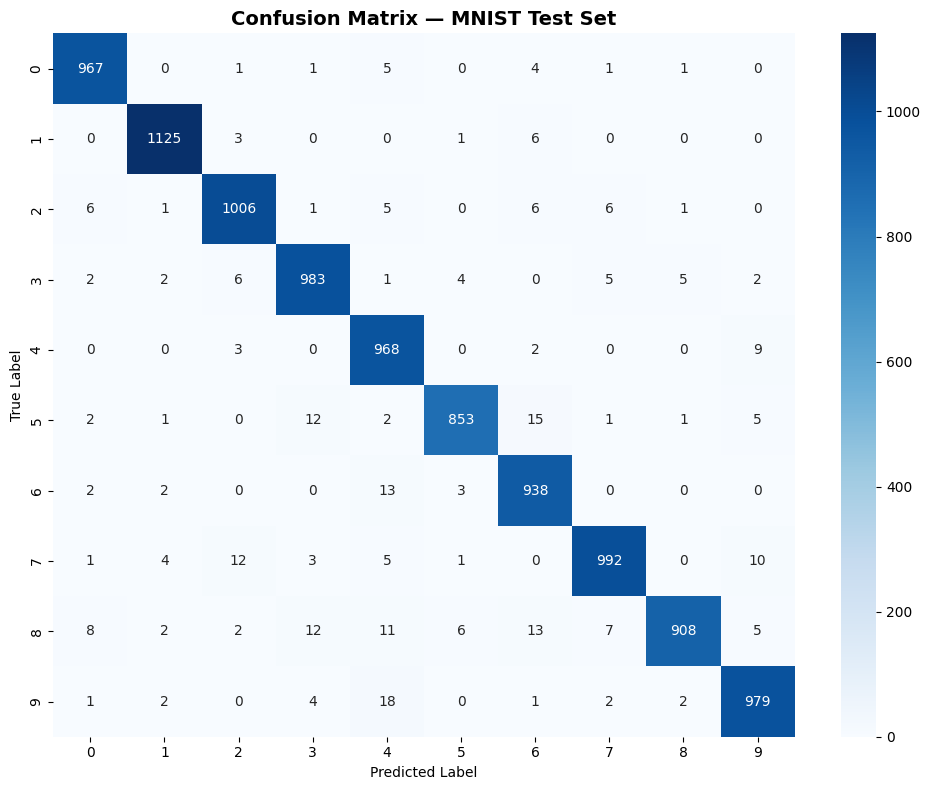

In [10]:
# Get predictions on the full test set
predictions_prob = model.predict(x_test_norm, verbose=0)

# Convert probability vectors → class indices (argmax picks the highest probability)
y_pred  = np.argmax(predictions_prob, axis=1)
y_true  = y_test   # original integer labels (no one-hot needed here)

# Build confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.title('Confusion Matrix — MNIST Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### Which Digits Does the Model Struggle With Most?

In [11]:
# Per-class accuracy: diagonal of confusion matrix / total per class
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("Per-Class Accuracy:")
print("-" * 30)
for digit, acc in enumerate(per_class_accuracy):
    bar = '█' * int(acc * 20)
    print(f"  Digit {digit}: {acc*100:5.1f}%  {bar}")

worst_digit = np.argmin(per_class_accuracy)
print(f"\nHardest digit for the model: {worst_digit} ({per_class_accuracy[worst_digit]*100:.1f}% accuracy)")

Per-Class Accuracy:
------------------------------
  Digit 0:  98.7%  ███████████████████
  Digit 1:  99.1%  ███████████████████
  Digit 2:  97.5%  ███████████████████
  Digit 3:  97.3%  ███████████████████
  Digit 4:  98.6%  ███████████████████
  Digit 5:  95.6%  ███████████████████
  Digit 6:  97.9%  ███████████████████
  Digit 7:  96.5%  ███████████████████
  Digit 8:  93.2%  ██████████████████
  Digit 9:  97.0%  ███████████████████

Hardest digit for the model: 8 (93.2% accuracy)


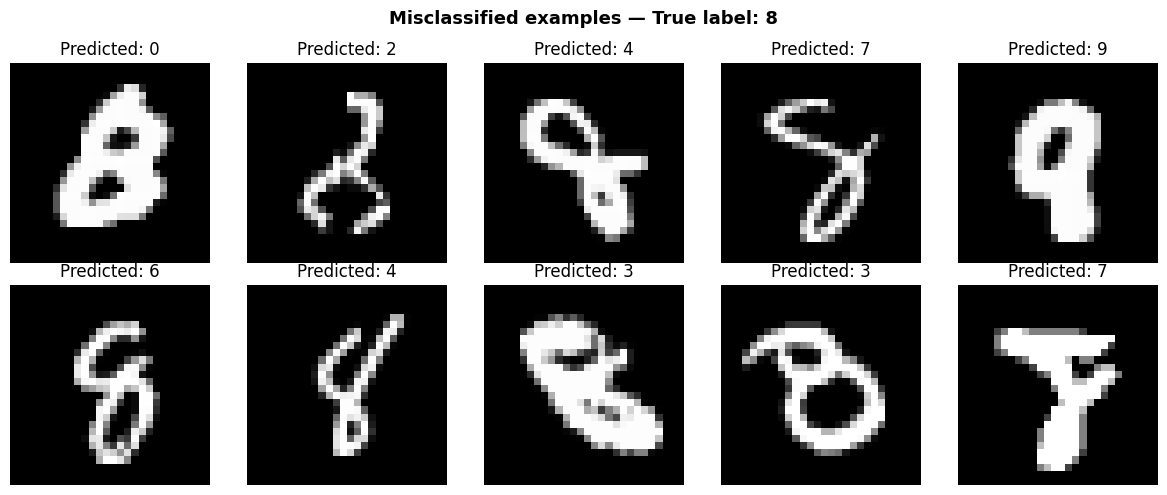

Total misclassified for digit 8: 66 / 974


In [12]:
# Show some misclassified examples for the hardest digit
misclassified_mask = (y_true == worst_digit) & (y_pred != worst_digit)
misclassified_indices = np.where(misclassified_mask)[0]

show_n = min(10, len(misclassified_indices))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle(f'Misclassified examples — True label: {worst_digit}', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < show_n:
        idx = misclassified_indices[i]
        ax.imshow(x_test[idx], cmap='gray')
        ax.set_title(f'Predicted: {y_pred[idx]}')
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Total misclassified for digit {worst_digit}: {misclassified_mask.sum()} / {(y_true == worst_digit).sum()}")

---
## Summary

| Step | What we did |
|------|-------------|
| Data | Loaded MNIST, normalized to [0,1], one-hot encoded labels |
| Model | Flatten → Dense(128, ReLU) → Dense(64, ReLU) → Dense(10, Softmax) |
| Training | 10 epochs, batch size 32, 20% validation split |
| Evaluation | Test accuracy, confusion matrix, per-class breakdown |

**Things to try next:**
- Add `Dropout` layers to reduce overfitting
- Try a CNN (Convolutional Neural Network) — better suited for image data
- Increase epochs with an `EarlyStopping` callback